Dataset Overview:
         exercise_name target_muscle_group      type  age gender  sets  reps  \
0  Barbell Bench Press               Chest  Compound   32      M     4    10   
1  Barbell Bench Press               Chest  Compound   28      F     3    12   
2  Barbell Bench Press               Chest  Compound   39      M     5     8   
3  Barbell Bench Press               Chest  Compound   35      F     4    10   
4  Barbell Bench Press               Chest  Compound   26      M     3    12   

   weight  frequency  protein  ...  sleep    experience  \
0      80          3      150  ...    7.5  Intermediate   
1      45          2      130  ...    7.2      Beginner   
2      90          4      170  ...    8.0      Advanced   
3      50          3      135  ...    7.4  Intermediate   
4      85          2      145  ...    7.6  Intermediate   

  muscle_size_increase_cm2  genetic_advantage  actual_fat_loss  daily_deficit  \
0                     2.50                  3             12.5   

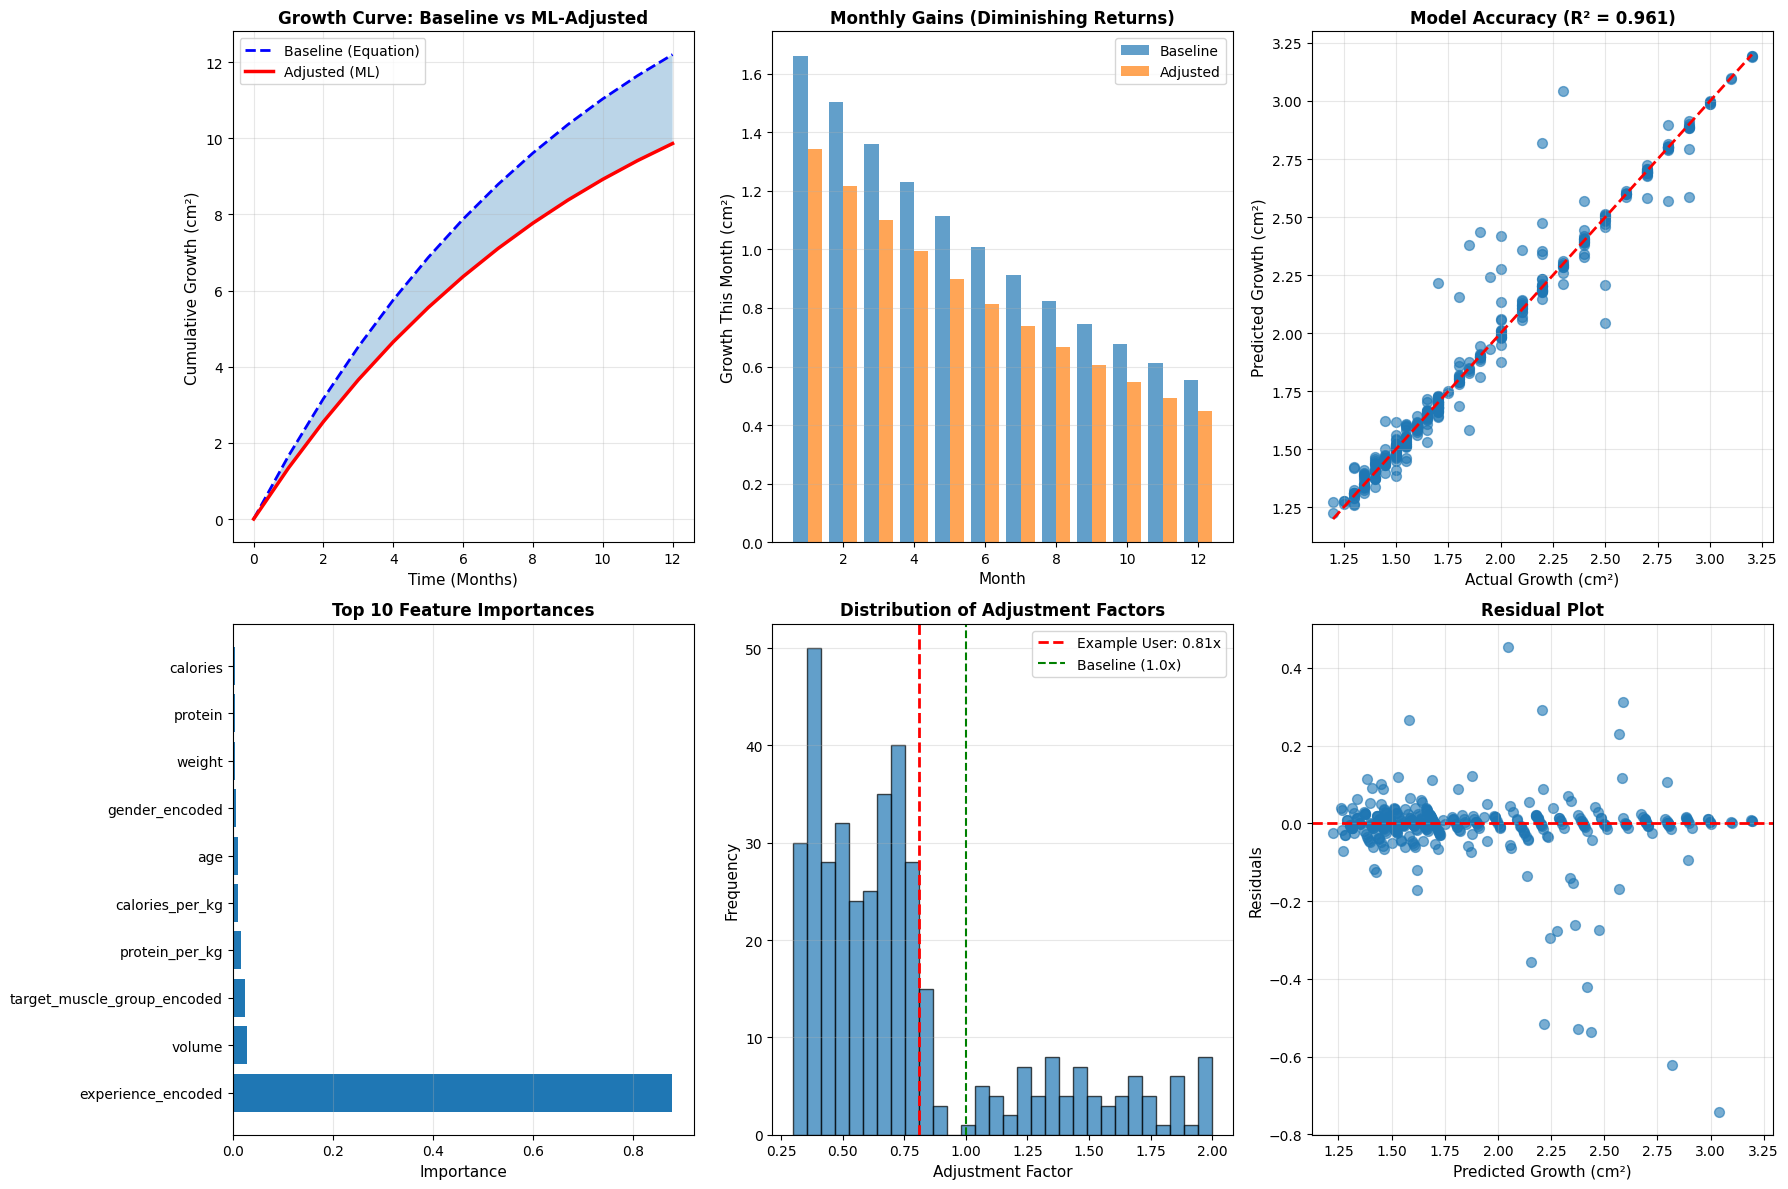


✅ Analysis complete! Visualization saved.

💾 Model saved to 'muscle_growth_model.pkl'

Use predict_muscle_growth_over_time() to make predictions for any user!


In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('MILESTONESmostCommonExercises.csv')

print("Dataset Overview:")
print(df.head())
print("\nDataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())

# ============================================================================
# MUSCLE GROWTH EQUATION PARAMETERS
# ============================================================================

def get_baseline_params(age, gender, experience):
    """
    Get baseline parameters for muscle growth equation
    Returns M_max (genetic limit) and k (growth rate constant)
    """
    
    # Genetic limit (M_max) in pounds of muscle
    if gender == 'M':
        base_limit = 45  # Male potential
        age_factor = max(0.6, 1 - (max(0, age - 25) * 0.01))  # Peak at 25
    else:  # Female
        base_limit = 28  # Female potential (60-65% of male)
        age_factor = max(0.6, 1 - (max(0, age - 25) * 0.008))
    
    M_max = base_limit * age_factor
    
    # Growth rate constant (k) based on experience
    # Higher k = faster approach to genetic limit
    k_values = {
        'Beginner': 0.20,      # Fast initial gains
        'Intermediate': 0.10,  # Moderate gains
        'Advanced': 0.05       # Slow gains near genetic limit
    }
    k = k_values.get(experience, 0.10)
    
    return M_max, k


def calculate_growth_curve(M_max, k, time_months):
    """
    Calculate cumulative muscle growth following exponential curve
    M(t) = M_max * (1 - e^(-k*t))
    
    Returns growth at each month from 0 to time_months
    """
    time_points = np.arange(0, time_months + 1)
    growth = M_max * (1 - np.exp(-k * time_points))
    return time_points, growth


def calculate_monthly_increments(M_max, k, time_months):
    """
    Calculate monthly growth increments (realistic diminishing returns)
    """
    _, cumulative_growth = calculate_growth_curve(M_max, k, time_months)
    
    # Calculate month-to-month increases
    monthly_gains = np.diff(cumulative_growth)
    monthly_gains = np.insert(monthly_gains, 0, cumulative_growth[0])  # Add initial month
    
    return monthly_gains


def pounds_to_cm2(pounds, muscle_group='overall'):
    """
    Convert pounds of muscle to approximate cm² cross-sectional area increase
    This is a rough approximation - actual conversion varies by muscle group
    """
    # Rough conversion factors (these would need calibration with real data)
    conversion_factors = {
        'Chest': 0.35,
        'Back': 0.30,
        'Quads': 0.40,
        'Arms': 0.25,
        'Shoulders': 0.28,
        'overall': 0.30
    }
    
    factor = conversion_factors.get(muscle_group, 0.30)
    return pounds * factor


# ============================================================================
# FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

# Encode categorical variables
label_encoders = {}
categorical_columns = ['gender', 'exercise_type', 'experience', 
                       'target_muscle_group', 'exercise_category']

for col in categorical_columns:
    if col in df.columns:
        le = LabelEncoder()
        df[f'{col}_encoded'] = le.fit_transform(df[col])
        label_encoders[col] = le

# Create advanced features
if 'weight' in df.columns and 'reps' in df.columns:
    df['total_volume'] = df['sets'] * df['reps'] * df['weight']
    df['intensity'] = df['weight'] / (df['reps'] + 1)  # Avoid division by zero

if 'protein' in df.columns and 'weight' in df.columns:
    # Assuming weight is in kg or converting appropriately
    df['protein_per_kg'] = df['protein'] / (df['weight'] * 0.45 + 1e-8)  # rough conversion, avoid division by zero
    df['protein_per_kg'] = df['protein_per_kg'].replace([np.inf, -np.inf], 0)  # Handle infinity

if 'calories' in df.columns and 'weight' in df.columns:
    df['calories_per_kg'] = df['calories'] / (df['weight'] * 0.45 + 1e-8)
    df['calories_per_kg'] = df['calories_per_kg'].replace([np.inf, -np.inf], 0)  # Handle infinity

if 'sets' in df.columns and 'reps' in df.columns:
    df['volume'] = df['sets'] * df['reps']

# Calculate baseline growth for each sample
# Assuming data represents growth over a specific time period (e.g., 3 months)
TRAINING_PERIOD_MONTHS = 3  # Adjust based on your data collection period

def calculate_baseline_for_row(row):
    """Calculate baseline growth for a specific time period"""
    M_max, k = get_baseline_params(row['age'], row['gender'], row['experience'])
    
    # Get total growth over training period
    baseline_pounds = M_max * (1 - np.exp(-k * TRAINING_PERIOD_MONTHS))
    
    # Convert to cm² based on muscle group
    muscle_group = row.get('target_muscle_group', 'overall')
    baseline_cm2 = pounds_to_cm2(baseline_pounds, muscle_group)
    
    return baseline_cm2

df['baseline_growth'] = df.apply(calculate_baseline_for_row, axis=1)

# Calculate adjustment factor
# This is what the ML model will learn to predict
if 'muscle_size_increase_cm2' in df.columns:
    target_column = 'muscle_size_increase_cm2'
elif 'muscle_growth' in df.columns:
    target_column = 'muscle_growth'
else:
    # Find the target column
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    target_column = [col for col in numeric_cols if 'muscle' in col.lower() or 'growth' in col.lower()]
    if target_column:
        target_column = target_column[0]
    else:
        print("Warning: Could not identify target column. Using first numeric column.")
        target_column = numeric_cols[0]

print(f"\nUsing '{target_column}' as target variable")

df['adjustment_factor'] = df[target_column] / (df['baseline_growth'] + 0.001)  # Avoid division by zero

print(f"\nAdjustment Factor Statistics:")
print(df['adjustment_factor'].describe())

# ============================================================================
# MODEL TRAINING
# ============================================================================

print("\n" + "="*80)
print("MODEL TRAINING")
print("="*80)

# Select features for the model
feature_columns = []

# Add encoded categorical features
for col in categorical_columns:
    if f'{col}_encoded' in df.columns:
        feature_columns.append(f'{col}_encoded')

# Add numeric features
numeric_features = ['age', 'sets', 'reps', 'weight', 'frequency', 
                   'protein', 'calories', 'sleep', 'volume', 'intensity',
                   'protein_per_kg', 'calories_per_kg', 'total_volume']

for feat in numeric_features:
    if feat in df.columns:
        feature_columns.append(feat)

print(f"\nFeatures used for training: {feature_columns}")

# Prepare data
X = df[feature_columns].fillna(0)  # Handle any missing values

# Replace any infinity values with 0
X = X.replace([np.inf, -np.inf], 0)

y = df['adjustment_factor']

# Remove outliers (adjustment factors beyond reasonable range)
mask = (y > 0.1) & (y < 3.0)
X = X[mask]
y = y[mask]
df_filtered = df[mask].copy()

print(f"\nDataset size after filtering: {len(X)} samples")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Train multiple models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, 
                                          min_samples_split=5, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                   learning_rate=0.05, random_state=42)
}

trained_models = {}
model_scores = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Test MAE: {test_mae:.4f}")
    print(f"  Test RMSE: {test_rmse:.4f}")
    
    trained_models[name] = model
    model_scores[name] = test_r2

# Select best model
best_model_name = max(model_scores, key=model_scores.get)
best_model = trained_models[best_model_name]
print(f"\n🏆 Best model: {best_model_name} (R² = {model_scores[best_model_name]:.4f})")

# Feature importance
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n📊 Top 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

# ============================================================================
# PREDICTION FUNCTION WITH REALISTIC TIME PROGRESSION
# ============================================================================

def predict_muscle_growth_over_time(
    age, gender, exercise_type, sets, reps, weight, frequency,
    protein, calories, sleep, experience, target_muscle_group,
    exercise_category, time_months, model=best_model
):
    """
    Predict realistic muscle growth over time with proper curve fitting
    
    Returns:
        - time_points: Array of month markers
        - baseline_curve: Baseline growth curve from equation
        - adjusted_curve: ML-adjusted realistic growth curve
        - monthly_gains: Month-to-month increases
    """
    
    # Get baseline parameters
    M_max, k = get_baseline_params(age, gender, experience)
    
    # Calculate baseline growth curve (in pounds)
    time_points, baseline_pounds = calculate_growth_curve(M_max, k, time_months)
    
    # Convert to cm² for the target muscle group
    baseline_cm2 = np.array([pounds_to_cm2(p, target_muscle_group) for p in baseline_pounds])
    
    # Prepare input for ML model
    input_data = pd.DataFrame({
        'age': [age],
        'gender': [gender],
        'exercise_type': [exercise_type],
        'sets': [sets],
        'reps': [reps],
        'weight': [weight],
        'frequency': [frequency],
        'protein': [protein],
        'calories': [calories],
        'sleep': [sleep],
        'experience': [experience],
        'target_muscle_group': [target_muscle_group],
        'exercise_category': [exercise_category]
    })
    
    # Encode categorical variables
    for col in categorical_columns:
        if col in input_data.columns and col in label_encoders:
            try:
                input_data[f'{col}_encoded'] = label_encoders[col].transform(input_data[col])
            except ValueError:
                # Handle unseen labels by using a default value (e.g., most frequent class)
                print(f"Warning: '{input_data[col].values[0]}' not in training data for {col}. Using default.")
                input_data[f'{col}_encoded'] = 0  # Default to first class
    
    # Create derived features
    input_data['volume'] = sets * reps
    input_data['intensity'] = weight / (reps + 1)
    input_data['total_volume'] = sets * reps * weight
    input_data['protein_per_kg'] = protein / (weight * 0.45)
    input_data['calories_per_kg'] = calories / (weight * 0.45)
    
    # Select features
    X_input = input_data[feature_columns].fillna(0)
    
    # Predict adjustment factor
    adjustment_factor = model.predict(X_input)[0]
    
    # Apply adjustment to entire curve (realistic scaling)
    adjusted_cm2 = baseline_cm2 * adjustment_factor
    
    # Calculate monthly gains (diminishing returns visible)
    baseline_monthly = np.diff(baseline_cm2)
    adjusted_monthly = np.diff(adjusted_cm2)
    
    return {
        'time_months': time_points,
        'baseline_cumulative': baseline_cm2,
        'adjusted_cumulative': adjusted_cm2,
        'baseline_monthly': baseline_monthly,
        'adjusted_monthly': adjusted_monthly,
        'adjustment_factor': adjustment_factor,
        'M_max_pounds': M_max,
        'growth_rate_k': k
    }

# ============================================================================
# EXAMPLE PREDICTION AND VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("EXAMPLE PREDICTION")
print("="*80)

# Example user input
example_params = {
    'age': 28,
    'gender': 'M',
    'exercise_type': 'Squats',
    'sets': 4,
    'reps': 8,
    'weight': 150,
    'frequency': 4,
    'protein': 160,
    'calories': 2800,
    'sleep': 7.5,
    'experience': 'Intermediate',
    'target_muscle_group': 'Quads',
    'exercise_category': 'Compound',
    'time_months': 12
}

result = predict_muscle_growth_over_time(**example_params)

print(f"\nUser Profile:")
print(f"  Age: {example_params['age']}, Gender: {example_params['gender']}, Experience: {example_params['experience']}")
print(f"  Exercise: {example_params['exercise_type']} ({example_params['exercise_category']})")
print(f"  Training: {example_params['sets']}x{example_params['reps']} @ {example_params['weight']}kg, {example_params['frequency']}x/week")
print(f"  Nutrition: {example_params['protein']}g protein, {example_params['calories']} cal/day")
print(f"  Recovery: {example_params['sleep']} hours sleep")

print(f"\nGenetic Parameters:")
print(f"  Maximum potential (M_max): {result['M_max_pounds']:.1f} lbs")
print(f"  Growth rate constant (k): {result['growth_rate_k']:.3f}")
print(f"  ML Adjustment Factor: {result['adjustment_factor']:.2f}x")

print(f"\nGrowth Predictions ({example_params['target_muscle_group']}):")
print(f"  Baseline at 12 months: {result['baseline_cumulative'][-1]:.2f} cm²")
print(f"  Adjusted at 12 months: {result['adjusted_cumulative'][-1]:.2f} cm²")

print(f"\nMonthly Breakdown (Adjusted):")
for month in [0, 1, 3, 6, 9, 12]:
    if month < len(result['adjusted_cumulative']):
        cumulative = result['adjusted_cumulative'][month]
        if month > 0:
            monthly_gain = result['adjusted_monthly'][month-1]
            print(f"  Month {month}: {cumulative:.2f} cm² total (+{monthly_gain:.2f} cm² this month)")
        else:
            print(f"  Month {month}: {cumulative:.2f} cm² (baseline)")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

fig = plt.figure(figsize=(18, 12))

# Plot 1: Growth Curves Comparison
ax1 = plt.subplot(2, 3, 1)
ax1.plot(result['time_months'], result['baseline_cumulative'], 
         'b--', label='Baseline (Equation)', linewidth=2)
ax1.plot(result['time_months'], result['adjusted_cumulative'], 
         'r-', label='Adjusted (ML)', linewidth=2.5)
ax1.fill_between(result['time_months'], result['baseline_cumulative'], 
                  result['adjusted_cumulative'], alpha=0.3)
ax1.set_xlabel('Time (Months)', fontsize=11)
ax1.set_ylabel('Cumulative Growth (cm²)', fontsize=11)
ax1.set_title('Growth Curve: Baseline vs ML-Adjusted', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Monthly Gains (Diminishing Returns)
ax2 = plt.subplot(2, 3, 2)
months_for_gains = result['time_months'][1:]
ax2.bar(months_for_gains - 0.2, result['baseline_monthly'], 
        width=0.4, label='Baseline', alpha=0.7)
ax2.bar(months_for_gains + 0.2, result['adjusted_monthly'], 
        width=0.4, label='Adjusted', alpha=0.7)
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Growth This Month (cm²)', fontsize=11)
ax2.set_title('Monthly Gains (Diminishing Returns)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Model Performance
ax3 = plt.subplot(2, 3, 3)
y_pred_all = best_model.predict(X)
actual_growth = df_filtered['baseline_growth'].values * y
predicted_growth = df_filtered['baseline_growth'].values * y_pred_all
ax3.scatter(df_filtered[target_column], predicted_growth, alpha=0.6, s=50)
ax3.plot([df_filtered[target_column].min(), df_filtered[target_column].max()],
         [df_filtered[target_column].min(), df_filtered[target_column].max()],
         'r--', linewidth=2)
ax3.set_xlabel('Actual Growth (cm²)', fontsize=11)
ax3.set_ylabel('Predicted Growth (cm²)', fontsize=11)
ax3.set_title(f'Model Accuracy (R² = {model_scores[best_model_name]:.3f})', 
              fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Feature Importance
ax4 = plt.subplot(2, 3, 4)
if hasattr(best_model, 'feature_importances_'):
    top_features = feature_importance.head(10)
    ax4.barh(range(len(top_features)), top_features['importance'])
    ax4.set_yticks(range(len(top_features)))
    ax4.set_yticklabels(top_features['feature'])
    ax4.set_xlabel('Importance', fontsize=11)
    ax4.set_title('Top 10 Feature Importances', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')

# Plot 5: Adjustment Factor Distribution
ax5 = plt.subplot(2, 3, 5)
ax5.hist(df_filtered['adjustment_factor'], bins=30, alpha=0.7, edgecolor='black')
ax5.axvline(result['adjustment_factor'], color='r', linestyle='--', 
            linewidth=2, label=f'Example User: {result["adjustment_factor"]:.2f}x')
ax5.axvline(1.0, color='g', linestyle='--', linewidth=1.5, label='Baseline (1.0x)')
ax5.set_xlabel('Adjustment Factor', fontsize=11)
ax5.set_ylabel('Frequency', fontsize=11)
ax5.set_title('Distribution of Adjustment Factors', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Residuals
ax6 = plt.subplot(2, 3, 6)
residuals = df_filtered[target_column] - predicted_growth
ax6.scatter(predicted_growth, residuals, alpha=0.6, s=50)
ax6.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax6.set_xlabel('Predicted Growth (cm²)', fontsize=11)
ax6.set_ylabel('Residuals', fontsize=11)
ax6.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('muscle_growth_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("✅ Analysis complete! Visualization saved.")
print("="*80)

# ============================================================================
# SAVE MODEL AND FUNCTION FOR FUTURE USE
# ============================================================================

import pickle

model_package = {
    'model': best_model,
    'feature_columns': feature_columns,
    'label_encoders': label_encoders,
    'training_period_months': TRAINING_PERIOD_MONTHS
}

with open('muscle_growth_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("\n💾 Model saved to 'muscle_growth_model.pkl'")
print("\nUse predict_muscle_growth_over_time() to make predictions for any user!")

In [7]:
# ============================================================================
# SAMPLE PREDICTION - Test the trained model with different user profiles
# ============================================================================

print("\n" + "="*80)
print("SAMPLE PREDICTIONS - TESTING DIFFERENT USER PROFILES")
print("="*80)

# Sample User 1: Beginner, Chest Focus
print("\n" + "-"*80)
print("USER 1: Beginner - Chest Focus (Bulking)")
print("-"*80)

user1_params = {
    'age': 22,
    'gender': 'M',
    'exercise_type': 'Barbell Bench Press',
    'sets': 4,
    'reps': 8,
    'weight': 100,
    'frequency': 4,
    'protein': 140,
    'calories': 2500,
    'sleep': 7.0,
    'experience': 'Beginner',
    'target_muscle_group': 'Chest',
    'exercise_category': 'Compound',
    'time_months': 12
}

result1 = predict_muscle_growth_over_time(**user1_params)

print(f"\nProfile:")
print(f"  Age: {user1_params['age']}, Gender: {user1_params['gender']}, Experience: {user1_params['experience']}")
print(f"  Exercise: {user1_params['exercise_type']} ({user1_params['exercise_category']})")
print(f"  Sets/Reps/Weight: {user1_params['sets']}x{user1_params['reps']}@{user1_params['weight']}kg")
print(f"  Frequency: {user1_params['frequency']}x/week")
print(f"  Nutrition: {user1_params['protein']}g protein, {user1_params['calories']} cal/day")
print(f"  Sleep: {user1_params['sleep']} hours")

print(f"\nGenetic Parameters:")
print(f"  M_max: {result1['M_max_pounds']:.1f} lbs")
print(f"  Growth Rate (k): {result1['growth_rate_k']:.3f}")
print(f"  ML Adjustment Factor: {result1['adjustment_factor']:.2f}x")

print(f"\nGrowth Predictions ({user1_params['target_muscle_group']}):")
print(f"  At 3 months: {result1['adjusted_cumulative'][3]:.2f} cm²")
print(f"  At 6 months: {result1['adjusted_cumulative'][6]:.2f} cm²")
print(f"  At 9 months: {result1['adjusted_cumulative'][9]:.2f} cm²")
print(f"  At 12 months: {result1['adjusted_cumulative'][12]:.2f} cm²")

print(f"\nMonthly Gains (Adjusted):")
for month in [1, 3, 6, 9, 12]:
    monthly_gain = result1['adjusted_monthly'][month-1]
    print(f"  Month {month}: +{monthly_gain:.2f} cm²")

# Sample User 2: Intermediate, Back Focus
print("\n" + "-"*80)
print("USER 2: Intermediate - Back Focus (Bulking)")
print("-"*80)

user2_params = {
    'age': 28,
    'gender': 'M',
    'exercise_type': 'Barbell Rows',
    'sets': 4,
    'reps': 6,
    'weight': 140,
    'frequency': 5,
    'protein': 170,
    'calories': 2800,
    'sleep': 8.0,
    'experience': 'Intermediate',
    'target_muscle_group': 'Back',
    'exercise_category': 'Compound',
    'time_months': 12
}

result2 = predict_muscle_growth_over_time(**user2_params)

print(f"\nProfile:")
print(f"  Age: {user2_params['age']}, Gender: {user2_params['gender']}, Experience: {user2_params['experience']}")
print(f"  Exercise: {user2_params['exercise_type']} ({user2_params['exercise_category']})")
print(f"  Sets/Reps/Weight: {user2_params['sets']}x{user2_params['reps']}@{user2_params['weight']}kg")
print(f"  Frequency: {user2_params['frequency']}x/week")
print(f"  Nutrition: {user2_params['protein']}g protein, {user2_params['calories']} cal/day")
print(f"  Sleep: {user2_params['sleep']} hours")

print(f"\nGenetic Parameters:")
print(f"  M_max: {result2['M_max_pounds']:.1f} lbs")
print(f"  Growth Rate (k): {result2['growth_rate_k']:.3f}")
print(f"  ML Adjustment Factor: {result2['adjustment_factor']:.2f}x")

print(f"\nGrowth Predictions ({user2_params['target_muscle_group']}):")
print(f"  At 3 months: {result2['adjusted_cumulative'][3]:.2f} cm²")
print(f"  At 6 months: {result2['adjusted_cumulative'][6]:.2f} cm²")
print(f"  At 9 months: {result2['adjusted_cumulative'][9]:.2f} cm²")
print(f"  At 12 months: {result2['adjusted_cumulative'][12]:.2f} cm²")

print(f"\nMonthly Gains (Adjusted):")
for month in [1, 3, 6, 9, 12]:
    monthly_gain = result2['adjusted_monthly'][month-1]
    print(f"  Month {month}: +{monthly_gain:.2f} cm²")

# Sample User 3: Advanced, Arms Focus
print("\n" + "-"*80)
print("USER 3: Advanced - Arms Focus (Bulking)")
print("-"*80)

user3_params = {
    'age': 35,
    'gender': 'M',
    'exercise_type': 'Barbell Curls',
    'sets': 3,
    'reps': 10,
    'weight': 50,
    'frequency': 3,
    'protein': 180,
    'calories': 2600,
    'sleep': 8.5,
    'experience': 'Advanced',
    'target_muscle_group': 'Arms',
    'exercise_category': 'Isolation',
    'time_months': 12
}

result3 = predict_muscle_growth_over_time(**user3_params)

print(f"\nProfile:")
print(f"  Age: {user3_params['age']}, Gender: {user3_params['gender']}, Experience: {user3_params['experience']}")
print(f"  Exercise: {user3_params['exercise_type']} ({user3_params['exercise_category']})")
print(f"  Sets/Reps/Weight: {user3_params['sets']}x{user3_params['reps']}@{user3_params['weight']}kg")
print(f"  Frequency: {user3_params['frequency']}x/week")
print(f"  Nutrition: {user3_params['protein']}g protein, {user3_params['calories']} cal/day")
print(f"  Sleep: {user3_params['sleep']} hours")

print(f"\nGenetic Parameters:")
print(f"  M_max: {result3['M_max_pounds']:.1f} lbs")
print(f"  Growth Rate (k): {result3['growth_rate_k']:.3f}")
print(f"  ML Adjustment Factor: {result3['adjustment_factor']:.2f}x")

print(f"\nGrowth Predictions ({user3_params['target_muscle_group']}):")
print(f"  At 3 months: {result3['adjusted_cumulative'][3]:.2f} cm²")
print(f"  At 6 months: {result3['adjusted_cumulative'][6]:.2f} cm²")
print(f"  At 9 months: {result3['adjusted_cumulative'][9]:.2f} cm²")
print(f"  At 12 months: {result3['adjusted_cumulative'][12]:.2f} cm²")

print(f"\nMonthly Gains (Adjusted):")
for month in [1, 3, 6, 9, 12]:
    monthly_gain = result3['adjusted_monthly'][month-1]
    print(f"  Month {month}: +{monthly_gain:.2f} cm²")

# Sample User 4: Female, Intermediate, Quads Focus
print("\n" + "-"*80)
print("USER 4: Female - Intermediate - Quads Focus (Bulking)")
print("-"*80)

user4_params = {
    'age': 26,
    'gender': 'F',
    'exercise_type': 'Squats',
    'sets': 4,
    'reps': 10,
    'weight': 80,
    'frequency': 4,
    'protein': 110,
    'calories': 2200,
    'sleep': 7.5,
    'experience': 'Intermediate',
    'target_muscle_group': 'Quads',
    'exercise_category': 'Compound',
    'time_months': 12
}

result4 = predict_muscle_growth_over_time(**user4_params)

print(f"\nProfile:")
print(f"  Age: {user4_params['age']}, Gender: {user4_params['gender']}, Experience: {user4_params['experience']}")
print(f"  Exercise: {user4_params['exercise_type']} ({user4_params['exercise_category']})")
print(f"  Sets/Reps/Weight: {user4_params['sets']}x{user4_params['reps']}@{user4_params['weight']}kg")
print(f"  Frequency: {user4_params['frequency']}x/week")
print(f"  Nutrition: {user4_params['protein']}g protein, {user4_params['calories']} cal/day")
print(f"  Sleep: {user4_params['sleep']} hours")

print(f"\nGenetic Parameters:")
print(f"  M_max: {result4['M_max_pounds']:.1f} lbs")
print(f"  Growth Rate (k): {result4['growth_rate_k']:.3f}")
print(f"  ML Adjustment Factor: {result4['adjustment_factor']:.2f}x")

print(f"\nGrowth Predictions ({user4_params['target_muscle_group']}):")
print(f"  At 3 months: {result4['adjusted_cumulative'][3]:.2f} cm²")
print(f"  At 6 months: {result4['adjusted_cumulative'][6]:.2f} cm²")
print(f"  At 9 months: {result4['adjusted_cumulative'][9]:.2f} cm²")
print(f"  At 12 months: {result4['adjusted_cumulative'][12]:.2f} cm²")

print(f"\nMonthly Gains (Adjusted):")
for month in [1, 3, 6, 9, 12]:
    monthly_gain = result4['adjusted_monthly'][month-1]
    print(f"  Month {month}: +{monthly_gain:.2f} cm²")

# Comparison Summary
print("\n" + "="*80)
print("PREDICTION SUMMARY COMPARISON")
print("="*80)

summary_data = {
    'User': ['User 1 (Beginner, Chest)', 'User 2 (Intermediate, Back)', 
             'User 3 (Advanced, Arms)', 'User 4 (Female, Quads)'],
    'Experience': [user1_params['experience'], user2_params['experience'],
                   user3_params['experience'], user4_params['experience']],
    'Muscle Group': [user1_params['target_muscle_group'], user2_params['target_muscle_group'],
                     user3_params['target_muscle_group'], user4_params['target_muscle_group']],
    '3-Month Growth': [result1['adjusted_cumulative'][3], result2['adjusted_cumulative'][3],
                       result3['adjusted_cumulative'][3], result4['adjusted_cumulative'][3]],
    '12-Month Growth': [result1['adjusted_cumulative'][12], result2['adjusted_cumulative'][12],
                        result3['adjusted_cumulative'][12], result4['adjusted_cumulative'][12]],
    'Adj. Factor': [result1['adjustment_factor'], result2['adjustment_factor'],
                    result3['adjustment_factor'], result4['adjustment_factor']]
}

summary_df = pd.DataFrame(summary_data)
print("\n")
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("Sample predictions complete!")
print("="*80)


SAMPLE PREDICTIONS - TESTING DIFFERENT USER PROFILES

--------------------------------------------------------------------------------
USER 1: Beginner - Chest Focus (Bulking)
--------------------------------------------------------------------------------

Profile:
  Age: 22, Gender: M, Experience: Beginner
  Exercise: Barbell Bench Press (Compound)
  Sets/Reps/Weight: 4x8@100kg
  Frequency: 4x/week
  Nutrition: 140g protein, 2500 cal/day
  Sleep: 7.0 hours

Genetic Parameters:
  M_max: 45.0 lbs
  Growth Rate (k): 0.200
  ML Adjustment Factor: 0.37x

Growth Predictions (Chest):
  At 3 months: 2.63 cm²
  At 6 months: 4.07 cm²
  At 9 months: 4.86 cm²
  At 12 months: 5.29 cm²

Monthly Gains (Adjusted):
  Month 1: +1.06 cm²
  Month 3: +0.71 cm²
  Month 6: +0.39 cm²
  Month 9: +0.21 cm²
  Month 12: +0.12 cm²

--------------------------------------------------------------------------------
USER 2: Intermediate - Back Focus (Bulking)
---------------------------------------------------------